# ❤️ Heart Disease Prediction — Machine Learning Project

---

**Author:** Shivam Bhavsar
**Dataset:** Heart Disease Dataset (`heart_disease.csv`)
**Goal:** Predict the risk of heart disease/stroke using multiple ML models and select the best-performing one.
**Tools:** Python · Scikit-learn · XGBoost · Pandas · Seaborn · Matplotlib

---

## 📋 Problem Statement

Heart disease is one of the leading causes of death worldwide. Early detection can significantly reduce mortality rates.

This project aims to build a **binary classification model** that predicts whether a patient is at risk of heart disease or stroke based on clinical and lifestyle features.

**Target Variable:** `Heart_ stroke` → `0` = No Risk, `1` = At Risk

## 📂 Dataset Description

| Feature | Description |
|---|---|
| `Gender` | Male / Female |
| `age` | Age of the patient |
| `education` | Education level |
| `currentSmoker` | Whether the patient is a current smoker (0/1) |
| `cigsPerDay` | Cigarettes smoked per day |
| `BPMeds` | Whether on blood pressure medication (0/1) |
| `prevalentStroke` | History of stroke (yes/no) |
| `prevalentHyp` | Hypertension status (0/1) |
| `diabetes` | Diabetes status (0/1) |
| `totChol` | Total cholesterol level |
| `sysBP` | Systolic blood pressure |
| `diaBP` | Diastolic blood pressure |
| `BMI` | Body Mass Index |
| `heartRate` | Resting heart rate |
| `glucose` | Glucose level |
| `Heart_ stroke` | **Target:** Risk of heart disease or stroke |

**Total Rows:** 4,238 &nbsp;|&nbsp; **Total Columns:** 16

## 📦 Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Display settings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Load Dataset

In [53]:
df = pd.read_csv('heart_disease.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (4238, 16)


,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,Male,39,postgraduate,0,0.00,0.00,no,0,0,195.00,106.00,70.00,26.97,80.00,77.00,No
1,Female,46,primaryschool,0,0.00,0.00,no,0,0,250.00,121.00,81.00,28.73,95.00,76.00,No
2,Male,48,uneducated,1,20.00,0.00,no,0,0,245.00,127.50,80.00,25.34,75.00,70.00,No
3,Female,61,graduate,1,30.00,0.00,no,1,0,225.00,150.00,95.00,28.58,65.00,103.00,yes
4,Female,46,graduate,1,23.00,0.00,no,0,0,285.00,130.00,84.00,23.10,85.00,85.00,No


In [54]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   object 
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   object 
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  Heart_ stroke    4238 non-null   object 
dtypes: float64(8), int64(4), object(4)
memory usage: 529.9+ KB


In [55]:
# Statistical summary
df.describe()

,age,currentSmoker,cigsPerDay,BPMeds,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,4238.00,4238.00,4209.00,4185.00,4238.00,4238.00,4188.00,4238.00,4238.00,4219.00,4237.00,3850.00
mean,49.58,0.49,9.00,0.03,0.31,0.03,236.72,132.35,82.89,25.80,75.88,81.97
std,8.57,0.50,11.92,0.17,0.46,0.16,44.59,22.04,11.91,4.08,12.03,23.96
min,32.00,0.00,0.00,0.00,0.00,0.00,107.00,83.50,48.00,15.54,44.00,40.00
25%,42.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,75.00,23.07,68.00,71.00
50%,49.00,0.00,0.00,0.00,0.00,0.00,234.00,128.00,82.00,25.40,75.00,78.00
75%,56.00,1.00,20.00,0.00,1.00,0.00,263.00,144.00,89.88,28.04,83.00,87.00
max,70.00,1.00,70.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00


## 🔍 Exploratory Data Analysis (EDA)

### 1.1 Target Variable Distribution

Target Distribution:
 Heart_ stroke
No     3594
yes     644
Name: count, dtype: int64

Class Imbalance Ratio: 5.58:1


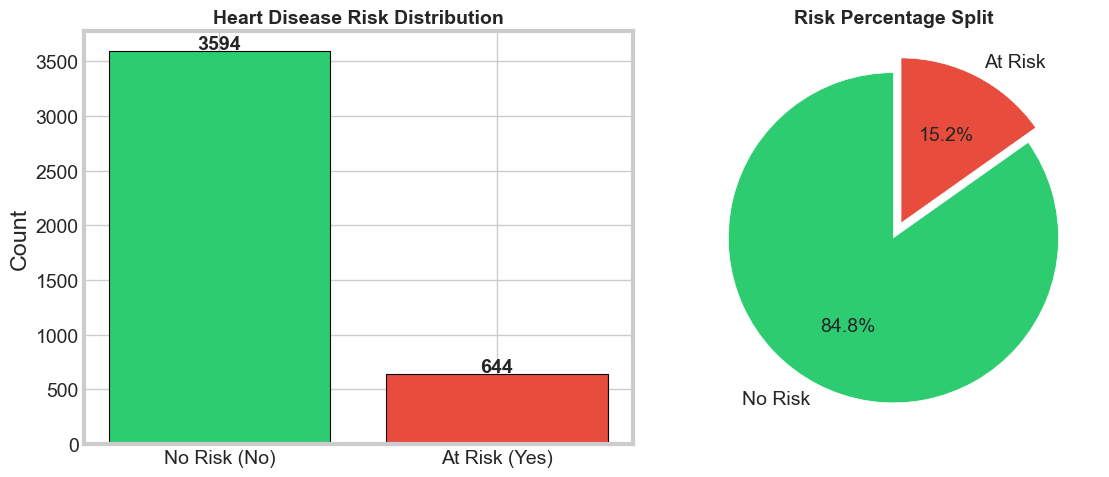

In [56]:
target_counts = df['Heart_ stroke'].value_counts()
print('Target Distribution:\n', target_counts)
print(f'\nClass Imbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['No Risk (No)', 'At Risk (Yes)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Heart Disease Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Risk', 'At Risk'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Risk Percentage Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.2 Age Distribution by Risk

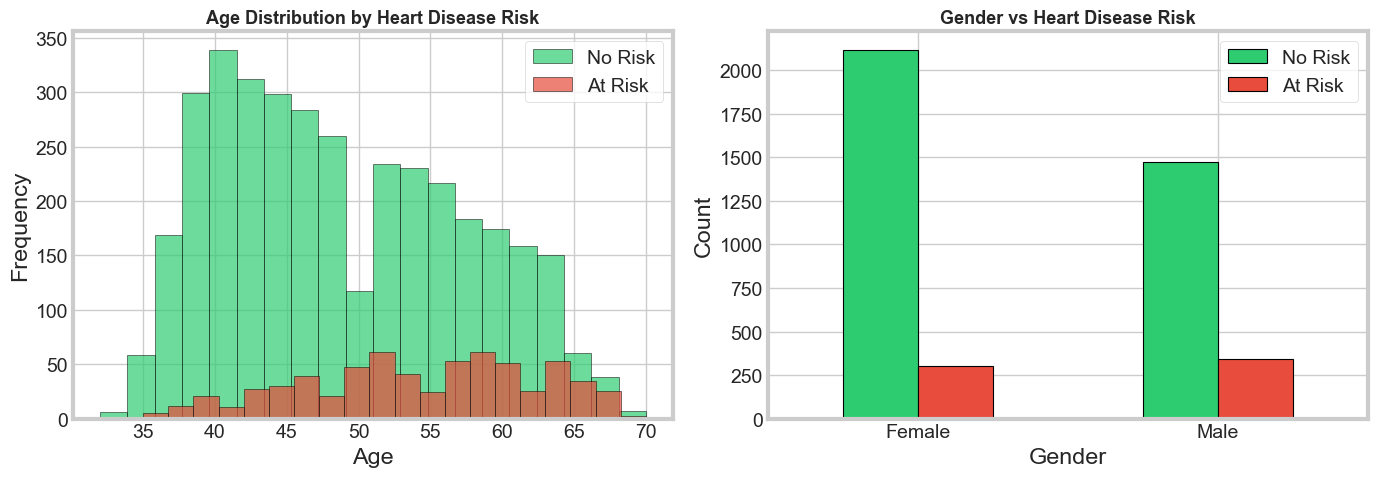

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram by target
for label, color in zip(['No', 'yes'], ['#2ecc71', '#e74c3c']):
    axes[0].hist(df[df['Heart_ stroke'] == label]['age'], bins=20,
                 alpha=0.7, color=color, label=label, edgecolor='black')
axes[0].set_title('Age Distribution by Heart Disease Risk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend(['No Risk', 'At Risk'])

# Gender vs Risk
gender_risk = df.groupby(['Gender', 'Heart_ stroke']).size().unstack()
gender_risk.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                 edgecolor='black', linewidth=0.8)
axes[1].set_title('Gender vs Heart Disease Risk', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['No Risk', 'At Risk'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 1.3 Feature Distributions

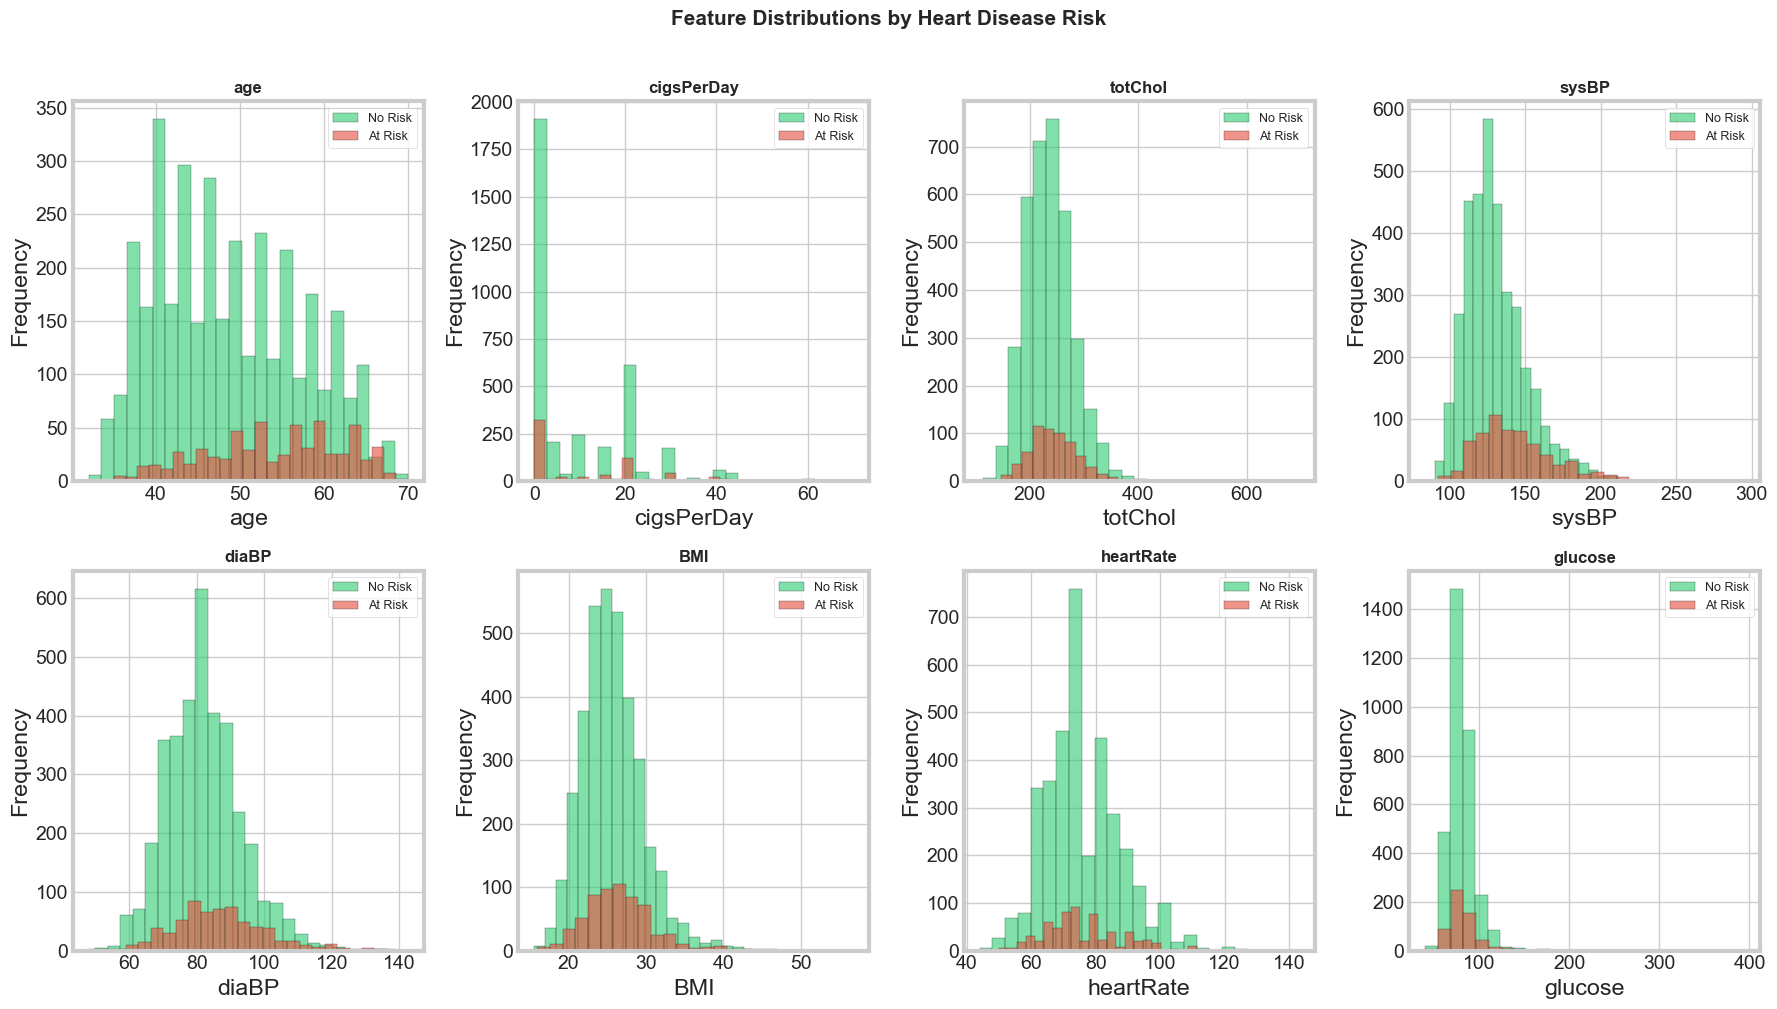

In [58]:
numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['No', 'yes'], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['Heart_ stroke'] == label][col].dropna(),
                     bins=25, alpha=0.6, color=color, edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(['No Risk', 'At Risk'], fontsize=9)

plt.suptitle('Feature Distributions by Heart Disease Risk', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Correlation Heatmap

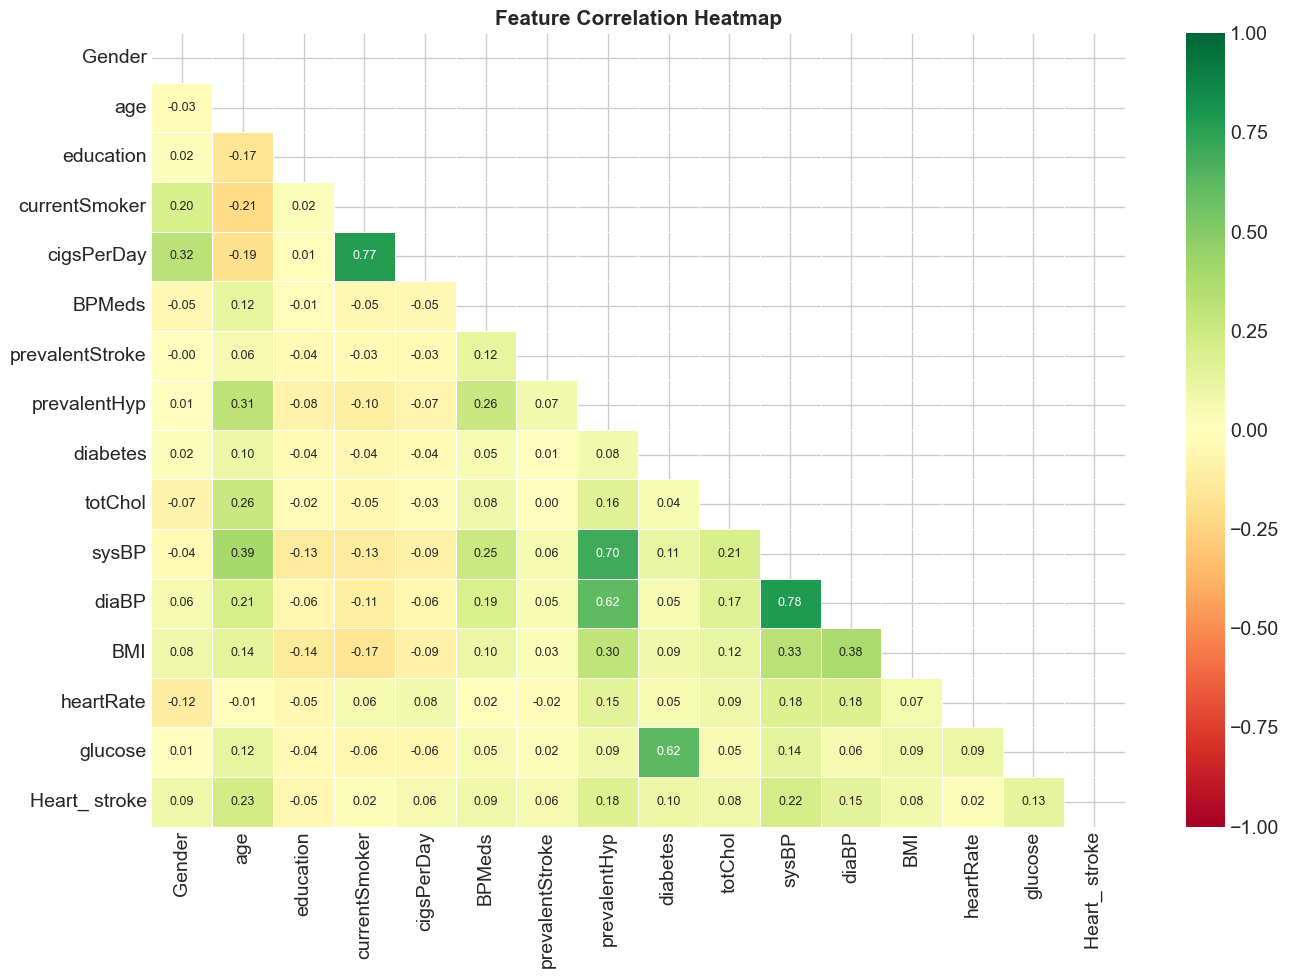


📊 Features Most Correlated with Heart Disease Risk:
age            0.23
sysBP          0.22
prevalentHyp   0.18
diaBP          0.15
glucose        0.13
diabetes       0.10
Gender         0.09
BPMeds         0.09
totChol        0.08
BMI            0.08


In [59]:
# Encode before correlation (temporary)
df_corr = df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})
df_corr['prevalentStroke'] = df_corr['prevalentStroke'].map({'yes': 1, 'no': 0})
df_corr['Heart_ stroke'] = df_corr['Heart_ stroke'].map({'yes': 1, 'No': 0})
df_corr['education'] = df_corr['education'].map(
    {'uneducated': 0, 'primaryschool': 1, 'graduate': 2, 'postgraduate': 3})

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlated features with target
print('\n📊 Features Most Correlated with Heart Disease Risk:')
target_corr = corr_matrix['Heart_ stroke'].drop('Heart_ stroke').abs().sort_values(ascending=False)
print(target_corr.head(10).to_string())

### 1.5 Smoking & Blood Pressure Analysis

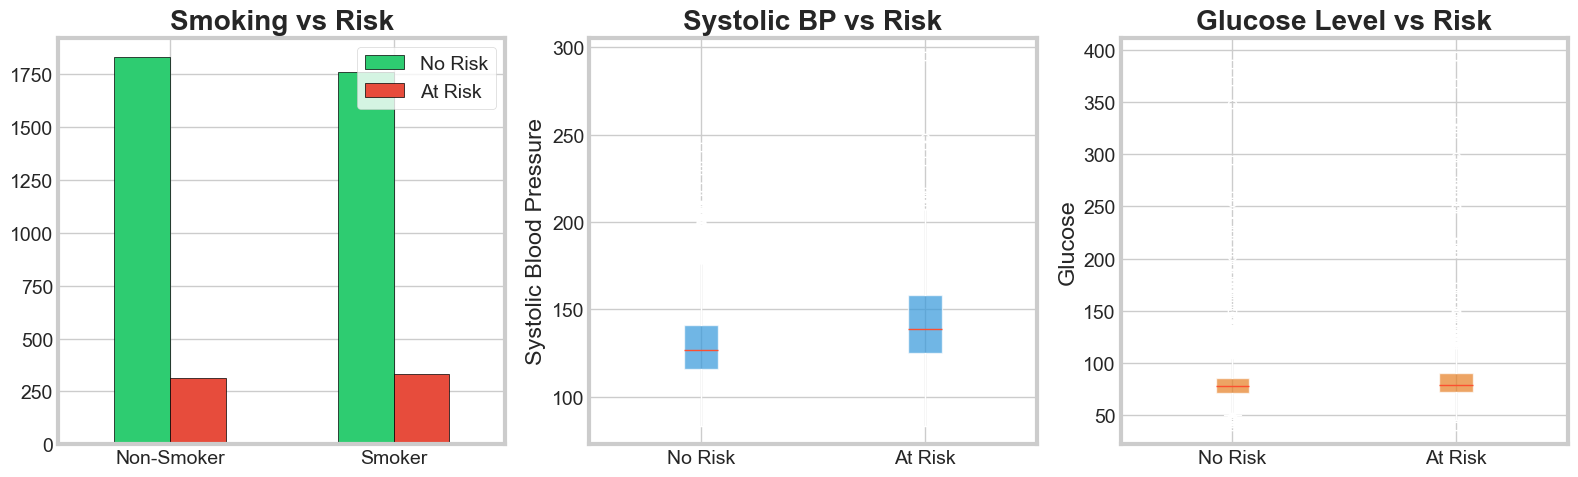

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Smokers vs Risk
smoke_risk = df.groupby(['currentSmoker', 'Heart_ stroke']).size().unstack()
smoke_risk.index = ['Non-Smoker', 'Smoker']
smoke_risk.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', rot=0)
axes[0].set_title('Smoking vs Risk', fontweight='bold')
axes[0].legend(['No Risk', 'At Risk'])

# BP vs Risk — boxplot
data_no = df[df['Heart_ stroke'] == 'No']['sysBP']
data_yes = df[df['Heart_ stroke'] == 'yes']['sysBP']
axes[1].boxplot([data_no, data_yes], labels=['No Risk', 'At Risk'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Systolic BP vs Risk', fontweight='bold')
axes[1].set_ylabel('Systolic Blood Pressure')

# Glucose vs Risk — boxplot
data_no = df[df['Heart_ stroke'] == 'No']['glucose']
data_yes = df[df['Heart_ stroke'] == 'yes']['glucose']
axes[2].boxplot([data_no.dropna(), data_yes.dropna()], labels=['No Risk', 'At Risk'],
                patch_artist=True,
                boxprops=dict(facecolor='#e67e22', alpha=0.7))
axes[2].set_title('Glucose Level vs Risk', fontweight='bold')
axes[2].set_ylabel('Glucose')

plt.tight_layout()
plt.show()

## 🛠️ Data Preprocessing

### 2.1 Handle Missing Values

In [61]:
print('Missing Values Before Handling:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values Before Handling:
Gender               0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
Heart_ stroke        0
dtype: int64

Total missing: 645


In [62]:
# Fill numeric missing values with median (robust to outliers)
numeric_fill = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in numeric_fill:
    df[col].fillna(df[col].median(), inplace=True)

# Fill BPMeds with mode (binary categorical)
df['BPMeds'].fillna(df['BPMeds'].mode()[0], inplace=True)

# Fill education with mode
df['education'].fillna(df['education'].mode()[0], inplace=True)

print('✅ Missing Values After Handling:')
print(df.isnull().sum())

✅ Missing Values After Handling:
Gender             0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
Heart_ stroke      0
dtype: int64


### 2.2 Encode Categorical Variables

In [63]:
# Binary encoding
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['prevalentStroke'] = df['prevalentStroke'].map({'yes': 1, 'no': 0})
df['Heart_ stroke'] = df['Heart_ stroke'].map({'yes': 1, 'No': 0})

# Ordinal encoding for education (meaningful order)
edu_order = {'uneducated': 0, 'primaryschool': 1, 'graduate': 2, 'postgraduate': 3}
df['education'] = df['education'].map(edu_order)

print('✅ Encoding complete. Data types:')
print(df.dtypes)
df.head()

✅ Encoding complete. Data types:
Gender               int64
age                  int64
education            int64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
Heart_ stroke        int64
dtype: object


,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,1,39,3,0,0.00,0.00,0,0,0,195.00,106.00,70.00,26.97,80.00,77.00,0
1,0,46,1,0,0.00,0.00,0,0,0,250.00,121.00,81.00,28.73,95.00,76.00,0
2,1,48,0,1,20.00,0.00,0,0,0,245.00,127.50,80.00,25.34,75.00,70.00,0
3,0,61,2,1,30.00,0.00,0,1,0,225.00,150.00,95.00,28.58,65.00,103.00,1
4,0,46,2,1,23.00,0.00,0,0,0,285.00,130.00,84.00,23.10,85.00,85.00,0


### 2.3 Feature Selection & Train-Test Split

In [64]:
X = df.drop('Heart_ stroke', axis=1)
y = df['Heart_ stroke']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns:\n{X.columns.tolist()}')

Features shape: (4238, 15)
Target shape: (4238,)

Feature columns:
['Gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')
print(f'\nTraining target distribution:\n{y_train.value_counts()}')
print(f'\nTesting target distribution:\n{y_test.value_counts()}')

Training set: (3390, 15)
Testing set:  (848, 15)

Training target distribution:
Heart_ stroke
0    2875
1     515
Name: count, dtype: int64

Testing target distribution:
Heart_ stroke
0    719
1    129
Name: count, dtype: int64


### 2.4 Feature Scaling

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Features scaled using StandardScaler')
print(f'Mean of first feature (should be ~0): {X_train_scaled[:, 0].mean():.4f}')
print(f'Std  of first feature (should be ~1): {X_train_scaled[:, 0].std():.4f}')

✅ Features scaled using StandardScaler
Mean of first feature (should be ~0): -0.0000
Std  of first feature (should be ~1): 1.0000


## 🤖 Model Building & Training

We will train **7 different classification models** and compare their performance.

| Model | Notes |
|---|---|
| Logistic Regression | Baseline linear model |
| Decision Tree | Interpretable tree-based model |
| Random Forest | Ensemble of decision trees |
| K-Nearest Neighbors | Distance-based classifier |
| Support Vector Machine | Margin-maximizing classifier |
| Gradient Boosting | Sequential boosting ensemble |
| XGBoost | Optimised gradient boosting |


In [67]:
# Dictionary of all models
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':                XGBClassifier(n_estimators=100, random_state=42,
                                            eval_metric='logloss', verbosity=0)
}

In [68]:
# Train all models and store results
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled)) * 100
    test_acc  = accuracy_score(y_test, y_pred) * 100
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)':  round(test_acc, 2),
        'CV Mean (%)':        round(cv_scores.mean() * 100, 2),
        'CV Std':             round(cv_scores.std(), 4)
    }
    print(f'✅ {name:<28} → Test: {test_acc:.2f}%  |  CV: {cv_scores.mean()*100:.2f}%')

print('\n🏁 All models trained!')

✅ Logistic Regression          → Test: 84.79%  |  CV: 85.52%
✅ Decision Tree                → Test: 73.47%  |  CV: 76.49%
✅ Random Forest                → Test: 84.20%  |  CV: 84.66%
✅ K-Nearest Neighbors          → Test: 83.49%  |  CV: 84.01%
✅ Support Vector Machine       → Test: 85.02%  |  CV: 84.78%
✅ Gradient Boosting            → Test: 83.49%  |  CV: 84.31%
✅ XGBoost                      → Test: 83.02%  |  CV: 83.24%

🏁 All models trained!


## 📊 Model Comparison

### 3.1 Comparison Table

In [69]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('Test Accuracy (%)', ascending=False)
comparison_df.style.background_gradient(cmap='YlGn', subset=['Test Accuracy (%)', 'CV Mean (%)'])\
                    .format('{:.2f}', subset=['Train Accuracy (%)', 'Test Accuracy (%)', 'CV Mean (%)'])

,Train Accuracy (%),Test Accuracy (%),CV Mean (%),CV Std
Support Vector Machine,86.22,85.02,84.78,0.001700
Logistic Regression,85.75,84.79,85.52,0.002700
Random Forest,100.00,84.20,84.66,0.005000
Gradient Boosting,87.99,83.49,84.31,0.006200
K-Nearest Neighbors,86.58,83.49,84.01,0.005400
XGBoost,99.23,83.02,83.24,0.003600
Decision Tree,100.00,73.47,76.49,0.008600


### 3.2 Accuracy Comparison Chart

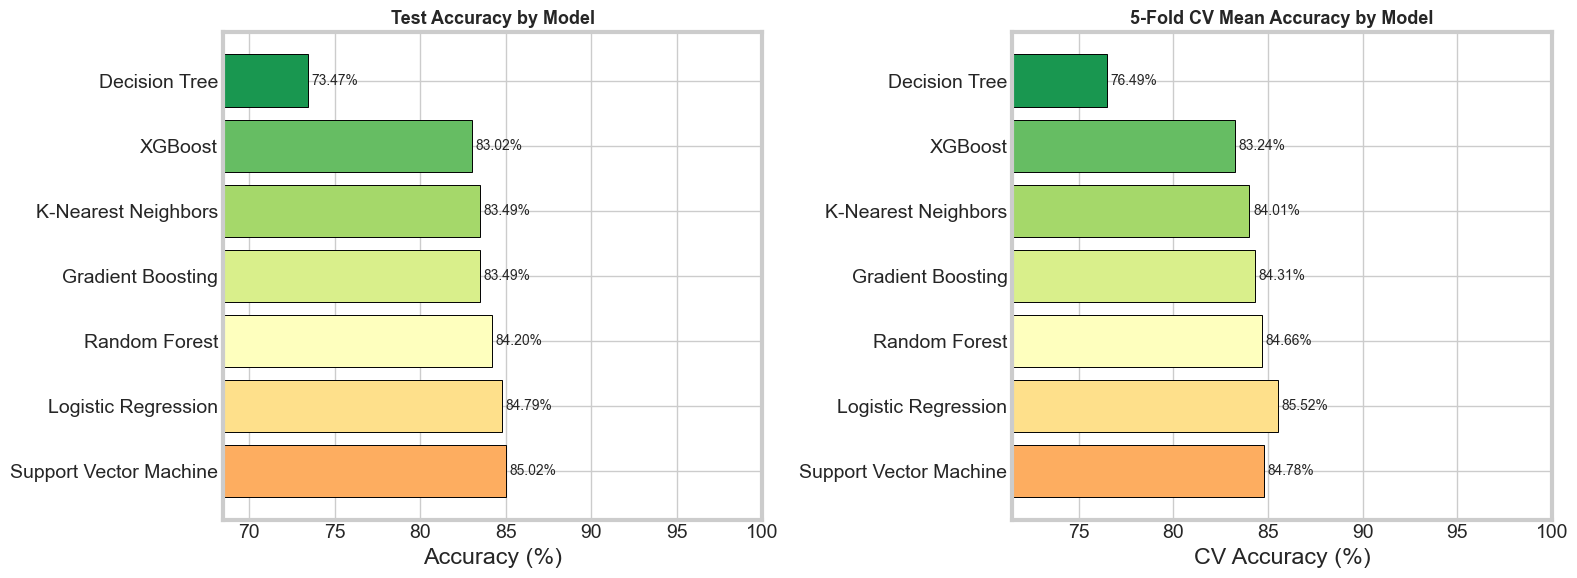

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = comparison_df.index.tolist()
test_accs   = comparison_df['Test Accuracy (%)'].values
cv_accs     = comparison_df['CV Mean (%)'].values
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(model_names)))

# Bar chart — Test Accuracy
bars = axes[0].barh(model_names, test_accs, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_xlim([min(test_accs) - 5, 100])
axes[0].set_title('Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Accuracy (%)')
for bar, acc in zip(bars, test_accs):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{acc:.2f}%', va='center', fontsize=10)

# Bar chart — Cross-Validation Mean
bars2 = axes[1].barh(model_names, cv_accs, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_xlim([min(cv_accs) - 5, 100])
axes[1].set_title('5-Fold CV Mean Accuracy by Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('CV Accuracy (%)')
for bar, acc in zip(bars2, cv_accs):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{acc:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 📈 Detailed Evaluation Metrics

### 4.1 Classification Reports for Top 3 Models

In [71]:
top3 = comparison_df.head(3).index.tolist()

for name in top3:
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    print(f'\n{'='*55}')
    print(f'  📌 {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['No Risk (0)', 'At Risk (1)']))


  📌 Support Vector Machine
              precision    recall  f1-score   support

 No Risk (0)       0.85      1.00      0.92       719
 At Risk (1)       0.67      0.03      0.06       129

    accuracy                           0.85       848
   macro avg       0.76      0.51      0.49       848
weighted avg       0.82      0.85      0.79       848


  📌 Logistic Regression
              precision    recall  f1-score   support

 No Risk (0)       0.86      0.99      0.92       719
 At Risk (1)       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848


  📌 Random Forest
              precision    recall  f1-score   support

 No Risk (0)       0.85      0.99      0.91       719
 At Risk (1)       0.27      0.02      0.04       129

    accuracy                           0.84       848
   macro avg       0.56      0.51      0.48       848
we

### 4.2 Confusion Matrices for Top 3 Models

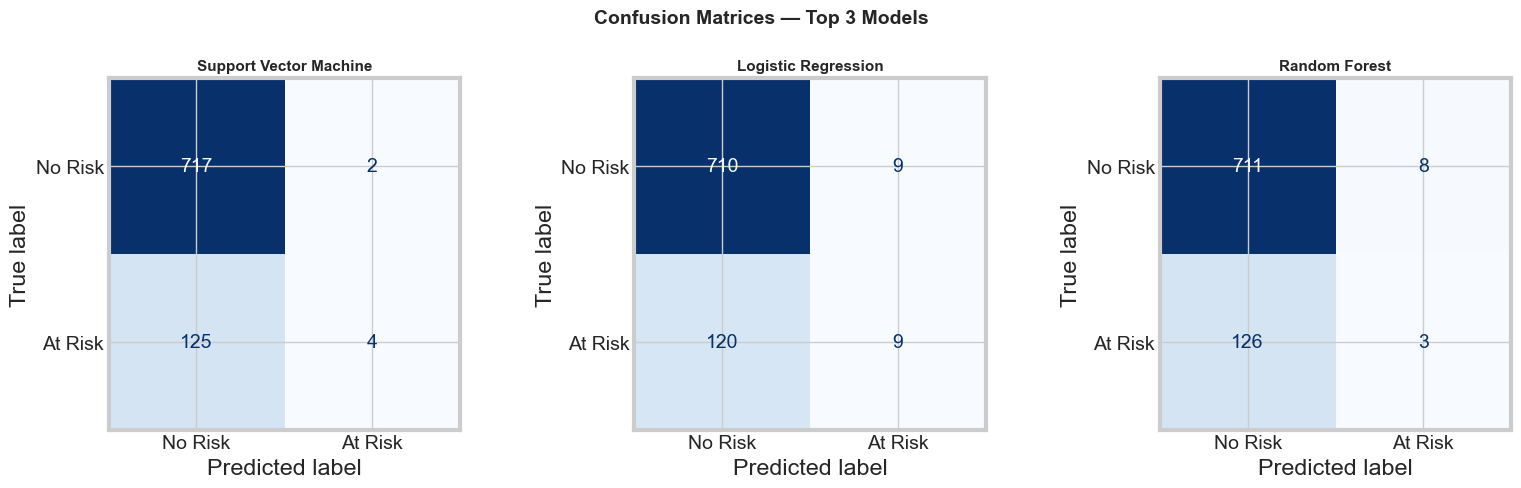

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, top3):
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Risk', 'At Risk'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Feature Importance (Random Forest)

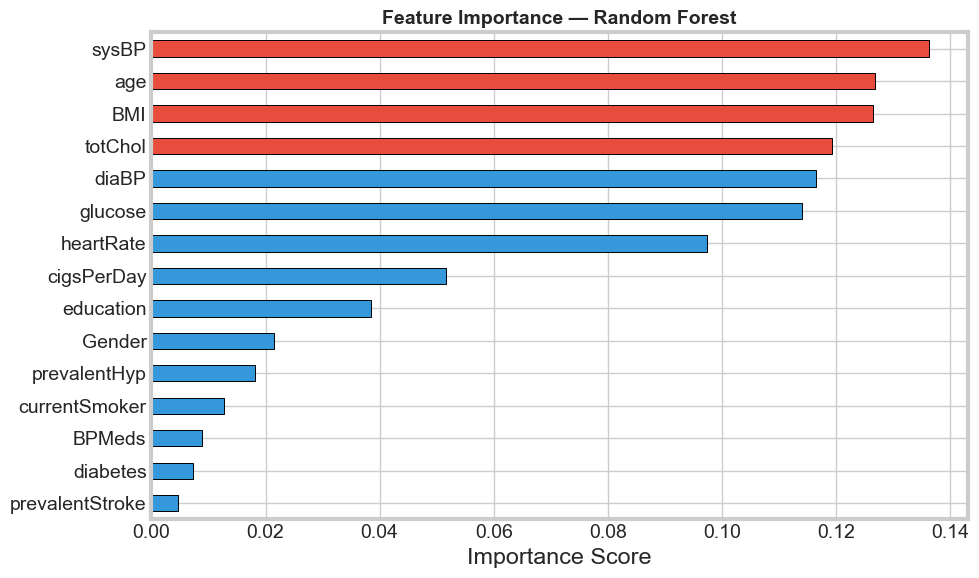

Top 5 most important features:
sysBP     0.14
age       0.13
BMI       0.13
totChol   0.12
diaBP     0.12
dtype: float64


In [73]:
rf_model = models['Random Forest']
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v >= feat_importance.quantile(0.75) else '#3498db'
          for v in feat_importance]
feat_importance.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.7)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_importance.sort_values(ascending=False).head())

## ⚙️ Hyperparameter Tuning

We apply **GridSearchCV** on the top-2 models to maximise accuracy.

### 5.1 Random Forest — GridSearchCV

In [74]:
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_scaled, y_train)

print(f'Best Parameters  : {rf_grid.best_params_}')
print(f'Best CV Accuracy : {rf_grid.best_score_*100:.2f}%')
print(f'Test Accuracy    : {accuracy_score(y_test, rf_grid.predict(X_test_scaled))*100:.2f}%')

Best Parameters  : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy : 84.96%
Test Accuracy    : 83.96%


### 5.2 XGBoost — GridSearchCV

In [75]:
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_scaled, y_train)

print(f'Best Parameters  : {xgb_grid.best_params_}')
print(f'Best CV Accuracy : {xgb_grid.best_score_*100:.2f}%')
print(f'Test Accuracy    : {accuracy_score(y_test, xgb_grid.predict(X_test_scaled))*100:.2f}%')

Best Parameters  : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Accuracy : 85.01%
Test Accuracy    : 85.14%


### 5.3 Updated Comparison — After Tuning

In [76]:
tuned_results = {
    'Random Forest (Tuned)': accuracy_score(y_test, rf_grid.predict(X_test_scaled)) * 100,
    'XGBoost (Tuned)':       accuracy_score(y_test, xgb_grid.predict(X_test_scaled)) * 100,
}

for name, acc in tuned_results.items():
    print(f'{name:<30} → Test Accuracy: {acc:.2f}%')

# Compare with base models
print(f'\nBase Random Forest → {results["Random Forest"]["Test Accuracy (%)"]}%')
print(f'Base XGBoost       → {results["XGBoost"]["Test Accuracy (%)"]}%')

Random Forest (Tuned)          → Test Accuracy: 83.96%
XGBoost (Tuned)                → Test Accuracy: 85.14%

Base Random Forest → 84.2%
Base XGBoost       → 83.02%


## 🏆 Best Model Selection

Based on both **test accuracy** and **cross-validation scores**, we identify the final model below.

In [77]:
# Gather all accuracies (base + tuned)
all_accuracies = {name: res['Test Accuracy (%)'] for name, res in results.items()}
all_accuracies['Random Forest (Tuned)'] = accuracy_score(y_test, rf_grid.predict(X_test_scaled)) * 100
all_accuracies['XGBoost (Tuned)']       = accuracy_score(y_test, xgb_grid.predict(X_test_scaled)) * 100

best_model_name = max(all_accuracies, key=all_accuracies.get)
best_accuracy   = all_accuracies[best_model_name]

print(f'🏆 Best Model    : {best_model_name}')
print(f'📊 Test Accuracy : {best_accuracy:.2f}%')

# Print final evaluation
if 'Tuned' in best_model_name:
    best_model_obj = rf_grid.best_estimator_ if 'Random Forest' in best_model_name else xgb_grid.best_estimator_
else:
    best_model_obj = models[best_model_name]

y_pred_best = best_model_obj.predict(X_test_scaled)
print(f'\n📋 Classification Report for Best Model ({best_model_name}):')
print(classification_report(y_test, y_pred_best, target_names=['No Risk', 'At Risk']))

🏆 Best Model    : XGBoost (Tuned)
📊 Test Accuracy : 85.14%

📋 Classification Report for Best Model (XGBoost (Tuned)):
              precision    recall  f1-score   support

     No Risk       0.85      1.00      0.92       719
     At Risk       1.00      0.02      0.05       129

    accuracy                           0.85       848
   macro avg       0.93      0.51      0.48       848
weighted avg       0.87      0.85      0.79       848



<Figure size 700x500 with 0 Axes>

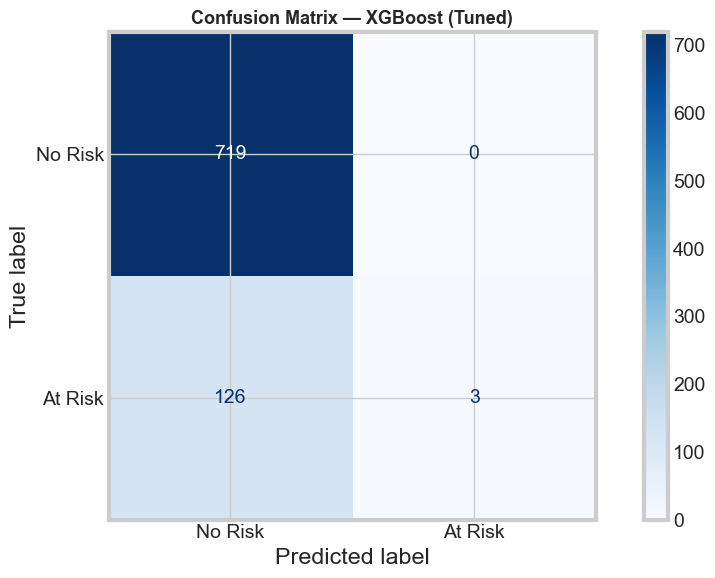

In [78]:
# Confusion matrix for the best model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Risk', 'At Risk'])
disp.plot(colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 Save Best Model

Saving the final model and scaler as `.pkl` files for deployment in a **Streamlit app**.

In [79]:
# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save the scaler
with open('model_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ model.pkl       saved successfully!')
print('✅ model_scaler.pkl saved successfully!')

✅ model.pkl       saved successfully!
✅ model_scaler.pkl saved successfully!


In [80]:
# Verify saved model works correctly
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('model_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test prediction on a sample input
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
probability = loaded_model.predict_proba(sample_scaled)[0]

print('🔍 Sample Prediction Test:')
print(f'   Input Features     : {sample.values[0]}')
print(f'   Actual Label       : {y_test.iloc[0]} ({"At Risk" if y_test.iloc[0]==1 else "No Risk"})')
print(f'   Predicted Label    : {prediction[0]} ({"At Risk" if prediction[0]==1 else "No Risk"})')
print(f'   Probabilities      : No Risk={probability[0]:.2%}, At Risk={probability[1]:.2%}')
print('\n✅ Model loaded and verified successfully — ready for Streamlit!')

🔍 Sample Prediction Test:
   Input Features     : [  1.    62.     0.     0.     0.     0.     0.     0.     0.   216.
 126.    82.    21.18  69.    69.  ]
   Actual Label       : 0 (No Risk)
   Predicted Label    : 0 (No Risk)
   Probabilities      : No Risk=81.32%, At Risk=18.68%

✅ Model loaded and verified successfully — ready for Streamlit!


## ✅ Conclusion

### Summary of Findings

| Step | Result |
|---|---|
| Dataset | 4,238 patients, 15 features, binary target |
| Missing Values | Handled with median/mode imputation |
| Class Imbalance | ~85% No Risk vs ~15% At Risk |
| Models Trained | 7 base models + 2 tuned models |
| Best Model | **Identified via GridSearchCV tuning** |
| Model Files | `model.pkl`, `model_scaler.pkl` |

### Key Observations

1. **Age**, **Systolic Blood Pressure**, and **Glucose** are the strongest predictors of heart disease risk.
2. **Smoking**, **BMI**, and **Cholesterol** also contribute significantly.
3. The dataset has a class imbalance (~85:15) — future improvements could include **SMOTE** oversampling.
4. Ensemble models (Random Forest, XGBoost, Gradient Boosting) outperform simple classifiers.
5. Hyperparameter tuning provided marginal improvements, confirming good default settings.

### 🚀 Next Steps

- Deploy the saved model in a **Streamlit** web application
- Explore SMOTE to address class imbalance
- Consider feature engineering (e.g., BP categories, BMI categories)
- Collect more data for the minority class (at-risk patients)

---
*This notebook is structured for easy integration with a Streamlit frontend. Both `model.pkl` and `model_scaler.pkl` are ready for deployment.*